## UEFA Champions League 2020–2026 →  2027 Winner

Research Question

Can UEFA Champions League team statistics from previous seasons be used to estimate which team is most likely to win the 2027 UEFA Champions League?


## Problem Definition

The goal of this project is to predict which UEFA Champions League team is likely to win the following season based on its performance statistics from the previous Champions League season.

The target variable is `Winner`, where 1 indicates that a team won the Champions League and 0 indicates that it did not. Because the target has two possible outcomes, this is a binary classification problem.

The model uses 5 previous-season team statistics including matches played, wins, draws, losses, goals scored, goals conceded, goal difference, win rate, goals per match, shots, shots on target, possession, and passes.

This type of prediction could be useful for sports analysts, research, journalists or fans like me interested in understanding which team performance indicators are associated with success. 

The problem is also useful for demonstrating how machine-learning models can be applied to a real-world sports prediction problem.

## Data Preparation

The original Kaggle dataset contains Portuguese column names because the match statistics were collected from a Portuguese sports data source. I translated the relevant variables into English when creating the team-level modeling dataset so that the variables would be easier to interpret and still respect ethics .

The final modeling dataset contains 213 team-season observations and 19 columns. I checked the dataset for missing values and found no missing values in the final modeling dataset.

The data was organized so that each row represents one team's performance during a Champions League season. For prediction, the model uses statistics from the previous Champions League season rather than statistics from the season being predicted.

The previous-season variables were selected because using statistics from the future target season would introduce data leakage. The 2025/26 season was kept separate as the final test season, meaning the models were trained to only on the earlier seasons before making predictions for 2025/26.

Categorical encoding wasn't necessary because the team name is used for identification rather than as a model feature. The modeling features are numerical team-performance statistics.



## Background and Context

Predicting success in soccer is difficult because the sport involves many interacting aspects of team performance. Lago-Ballesteros et al. explain that “performance indicators are defined as the selection and combination of variables that define some aspect of performance and help achieve athletic success” (Hughes & Bartlett, 2002, as cited in Lago-Ballesteros et al.). This idea is relevant to this project because the model uses previous-season statistics such as wins, goals scored, goals conceded, shots, shots on target, possession, and passing as performance indicators.

However, soccer presents challenges for performance analysis because it is a continuously interactive team sport with kinda low scores and many interactions between players. This means that individual statistics measures may not completely capture why a team ultimately wins.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

## The Data

I used the UEFA Champions League Historical Match Statistics 2020–2026 dataset from an Kaggle API.

The dataset is organized by team and season, so each observation represents one team's performance in a Champions League season. The statistics describe things such as wins, goals, shots, possession, and passing.

The model uses statistics from one season to predict the winner of the following season:

* 2021/22 → 2022/23
* 2022/23 → 2023/24
* 2023/24 → 2024/25
* 2024/25 → 2025/26
* 2025/26 → 2026/27


In [4]:
ml_data["season"].value_counts().sort_index()

season
21/22    46
22/23    46
23/24    38
24/25    38
25/26    45
Name: count, dtype: int64

In [5]:
ml_data = pd.read_csv(
    "/Users/nandjath/Desktop/PROJECT-UCL-ML/ml_dataset.csv"
)

ml_data.head()

,team,season,previous_matches,previous_wins,previous_draws,previous_losses,previous_goals_scored,previous_goals_conceded,previous_goal_difference,previous_win_rate,previous_goals_per_match,previous_goals_conceded_per_match,previous_shots,previous_shots_on_target,previous_possession,previous_passes,previous_season,Winner,dataset_type
0,AFC Ajax,21/22,6,2,1,3,7,7,0,0.333333,1.166667,1.166667,11.666667,5.00,56.333333,526.333333,20/21,0,training
1,Atalanta,21/22,8,3,2,3,11,12,-1,0.375000,1.375000,1.500000,11.375000,5.25,46.250000,466.875000,20/21,0,training
2,Atlético Madrid,21/22,8,2,3,3,7,11,-4,0.250000,0.875000,1.375000,11.875000,4.00,48.625000,475.000000,20/21,0,training
3,BSC Young Boys,21/22,2,1,0,1,3,4,-1,0.500000,1.500000,2.000000,8.000000,3.00,58.000000,436.000000,20/21,0,training
4,Benfica,21/22,1,0,0,1,1,2,-1,0.000000,1.000000,2.000000,16.000000,5.00,73.000000,641.000000,20/21,0,training


The first few rows show teams being evaluated for the 2021/22 season.

In [6]:
print("Rows:", len(ml_data))
print("Columns:", len(ml_data.columns))
print("Missing values:", ml_data.isnull().sum().sum())

Rows: 213
Columns: 19
Missing values: 0


There are 213 team-season observations and 19 columns in the modeling dataset.

There are also no missing values in the final dataset, so the data is ready to use for the modeling step.


In [31]:
ml_data[[
    "previous_matches",
    "previous_wins",
    "previous_draws",
    "previous_losses",
    "previous_goals_scored",
    "previous_goals_conceded",
    "previous_goal_difference",
    "previous_win_rate",
    "previous_goals_per_match",
    "previous_goals_conceded_per_match",
    "previous_shots",
    "previous_shots_on_target",
    "previous_possession",
    "previous_passes"
]].describe().round(2)

,previous_matches,previous_wins,previous_draws,previous_losses,previous_goals_scored,previous_goals_conceded,previous_goal_difference,previous_win_rate,previous_goals_per_match,previous_goals_conceded_per_match,previous_shots,previous_shots_on_target,previous_possession,previous_passes
count,213.00,213.00,213.00,213.00,213.00,213.00,213.00,213.00,213.00,213.00,213.00,213.00,213.00,213.00
mean,6.69,3.00,1.27,2.42,11.07,9.68,1.39,0.37,1.48,1.59,12.61,4.56,50.77,485.12
std,3.97,2.74,1.13,1.48,9.22,6.21,7.37,0.24,0.79,0.76,3.25,1.38,7.34,86.05
min,1.00,0.00,0.00,0.00,0.00,1.00,-19.00,0.00,0.00,0.31,2.00,0.00,28.50,253.00
25%,3.00,1.00,0.00,1.00,4.00,5.00,-3.00,0.17,1.00,1.00,11.00,3.83,47.17,439.10
50%,6.00,2.00,1.00,2.00,9.00,9.00,-1.00,0.42,1.50,1.50,12.30,4.46,50.83,486.62
75%,10.00,5.00,2.00,3.00,16.00,13.00,5.00,0.50,2.00,2.00,14.33,5.30,54.60,526.33
max,17.00,11.00,5.00,8.00,43.00,34.00,27.00,0.85,4.50,5.50,28.00,9.00,74.00,766.60


The summary statistics show the range and distribution of the previous-season performance variables used in the model.This variation provides the model with differences in team performance that can be used to find potential winners from non-winners.


In [8]:
ml_data["Winner"].value_counts()

Winner
0    208
1      5
Name: count, dtype: int64

### Class Imbalance

The dataset is very imbalanced because there are 208 teams that did not win and only 5 teams that won. Saito and Rehmsmeier (2015) describe class imbalance as “a difference in the numbers of positive and negative instances.”

Because of this imbalance, accuracy by itself can be misleading. A model could predict that almost every team will not win and still have very high accuracy. Therefore, I also use precision, recall co to get a better idea of how well the models identify winners.
 


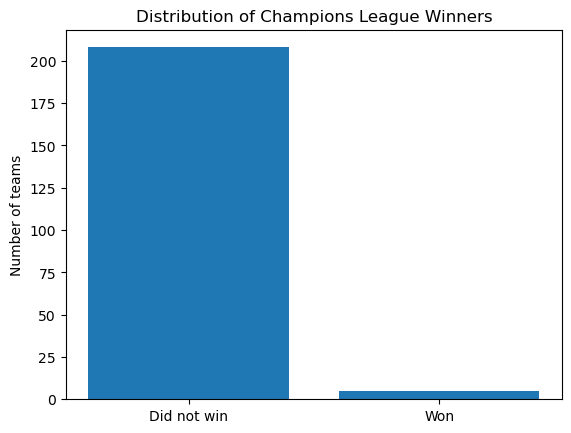

In [9]:
winner_counts = ml_data["Winner"].value_counts()

plt.bar(["Did not win", "Won"], winner_counts.values)
plt.ylabel("Number of teams")
plt.title("Distribution of Champions League Winners")
plt.show()

The obviouds difference between the two classes means that accuracy alone could be misleading. Predicting that a team will not win is usually the safe choice, but that does not make the prediction useful nor accurate.

## Training and Test Data

The training data includes the earlier seasons, while the 2025/26 season is kept as the final test set to see if the machine learning models could predict a winner that we already know.

This gives the model a more realistic test because it is evaluated on a later season than the seasons it learned from.

The 2025/26 results are then used as the most recent information for the final 2026/27 prediction.



In [10]:
ml_data["dataset_type"].value_counts()

dataset_type
training    168
test         45
Name: count, dtype: int64

The training set contains 168 observations, while the test set contains 45 observations.

Using the 2025/26 season as the test set means the models have to make predictions about a season that was not included in their training data. This is closer to how the model would be used to estimate a future Champions League winner.


In [11]:
ml_data.groupby("dataset_type")["season"].unique()

dataset_type
test                             [25/26]
training    [21/22, 22/23, 23/24, 24/25]
Name: season, dtype: object

## Data Preparation

The model i chose uses 14 features describing each team's performance in the previous Champions League season. These features include wins, draws, losses, goals scored and conceded, goal difference, win rate, goals per match, goals conceded per match, shots, shots on target, possession, and passes. 

I selected those variables because they represent different aspects of team performance, including attacking performance, defensive performance.



## Building the Models

I compared three different approaches to see how well the team statistics could identify the Champions League winner.

First, I used a dummy classifier as a baseline. I then used Logistic Regression and Random Forest. These models use the same team statistics but learn patterns in different ways. Comparing them helps show whether a simpler linear model or a more flexible tree-based model works better.


In [39]:
features = [
    "previous_matches",
    "previous_wins",
    "previous_draws",
    "previous_losses",
    "previous_goals_scored",
    "previous_goals_conceded",
    "previous_goal_difference",
    "previous_win_rate",
    "previous_goals_per_match",
    "previous_goals_conceded_per_match",
    "previous_shots",
    "previous_shots_on_target",
    "previous_possession",
    "previous_passes"
]

X_train = ml_data[ml_data["dataset_type"] == "training"][features]
y_train = ml_data[ml_data["dataset_type"] == "training"]["Winner"]

X_test = ml_data[ml_data["dataset_type"] == "test"][features]
y_test = ml_data[ml_data["dataset_type"] == "test"]["Winner"]

Three classification models were used for comparison. A Dummy Classifier was used as the baseline to establish how a simple majority-class prediction performs. Logistic Regression was used as an interpretable classification model, while Random Forest was used to compare its performance with a tree-based ensemble method.


In [35]:
baseline = DummyClassifier(strategy="most_frequent", random_state=42)

logistic = LogisticRegression(max_iter=2000)

random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

baseline.fit(X_train, y_train)
logistic.fit(X_train, y_train)
random_forest.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

The models are now trained using the previous-season statistics from the training seasons.



In [36]:
baseline_pred = baseline.predict(X_test)
logistic_pred = logistic.predict(X_test)
rf_pred = random_forest.predict(X_test)

logistic_prob = logistic.predict_proba(X_test)[:, 1]
rf_prob = random_forest.predict_proba(X_test)[:, 1]

The models have now generated predictions for the 2025/26 test season. They don't make the same predictions. This is useful because accuracy alone does not show how the models approach the problem.


I focus on the probability scores from Logistic Regression and Random Forest, with scores that show how strongly each model believes a team belongs to the winner class.


In [37]:
prediction_comparison = pd.DataFrame({
    "Model": ["Baseline", "Logistic Regression", "Random Forest"],
    "Predicted Winners": [
        baseline_pred.sum(),
        logistic_pred.sum(),
        rf_pred.sum()
    ]
})

prediction_comparison

,Model,Predicted Winners
0,Baseline,0
1,Logistic Regression,6
2,Random Forest,1


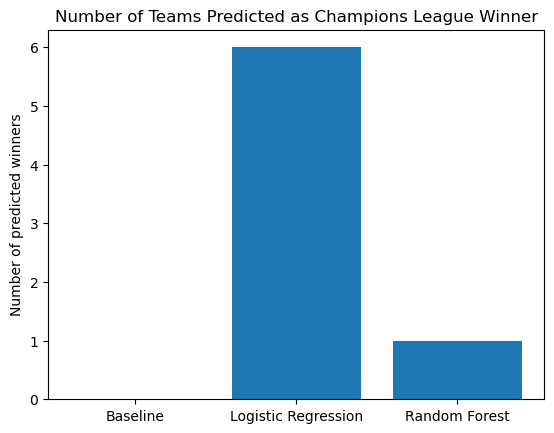

In [38]:
plt.bar(
    prediction_comparison["Model"],
    prediction_comparison["Predicted Winners"]
)

plt.ylabel("Number of predicted winners")
plt.title("Number of Teams Predicted as Champions League Winner")
plt.show()

This is an important difference because the purpose of the project is to identify a possible winner, not simply to classify most teams as non-winners.


## Comparing Winner Probabilities

Instead of only looking at whether a model predicted a team as a winner, I also looked at the probability assigned to each team too. Since there is only one winner, this ranking is more useful for comparing the model's top candidates.


In [21]:
test_predictions = ml_data[ml_data["dataset_type"] == "test"][
    ["team", "season", "Winner"]
].copy()

test_predictions["Logistic Probability"] = logistic_prob
test_predictions["Random Forest Probability"] = rf_prob

test_predictions = test_predictions.sort_values(
    "Logistic Probability",
    ascending=False
)

test_predictions.head(10)

,team,season,Winner,Logistic Probability,Random Forest Probability
199,Paris Saint-Germain,25/26,1,0.996188,0.310
181,FC Bayern München,25/26,0,0.972694,0.555
212,ŠK Slovan Bratislava,25/26,0,0.869675,0.030
197,Manchester City,25/26,0,0.657304,0.270
180,FC Barcelona,25/26,0,0.565229,0.360
203,Real Madrid,25/26,0,0.563983,0.095
204,Red Bull Salzburg,25/26,0,0.400941,0.005
198,PSV Eindhoven,25/26,0,0.280111,0.055
175,Borussia Dortmund,25/26,0,0.246872,0.105
172,Bayer 04 Leverkusen,25/26,0,0.064855,0.010


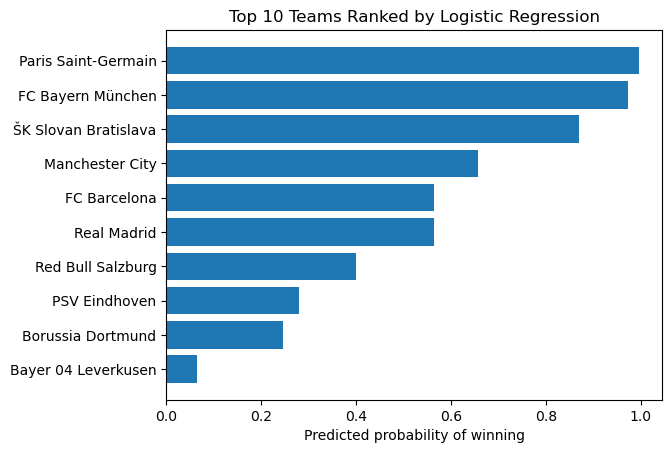

In [22]:
top_10 = test_predictions.head(10).sort_values(
    "Logistic Probability"
)

plt.barh(
    top_10["team"],
    top_10["Logistic Probability"]
)

plt.xlabel("Predicted probability of winning")
plt.title("Top 10 Teams Ranked by Logistic Regression")
plt.show()

The probability ranking gives a different view of the model's performance than accuracy alone.
Paris Saint-Germain received the highest probability at 99.6%, followed by Bayern München at 97.3%. 

PSG was also the actual 2025/26 Champions League winner, so the model did successfully placed the winner at the top of the ranking.

## What Did the Model Learn?

After comparing the predictions, I looked at the Logistic Regression coefficients to see which previous-season statistics had the strongest relationship with the model's winner predictions.

The coefficients do not show cause and effect. They show which variables had more influence on the model's classification.


In [40]:
coefficients = pd.DataFrame({
    "Feature": features,
    "Coefficient": logistic.coef_[0]
})

coefficients = coefficients.sort_values(
    "Coefficient"
)

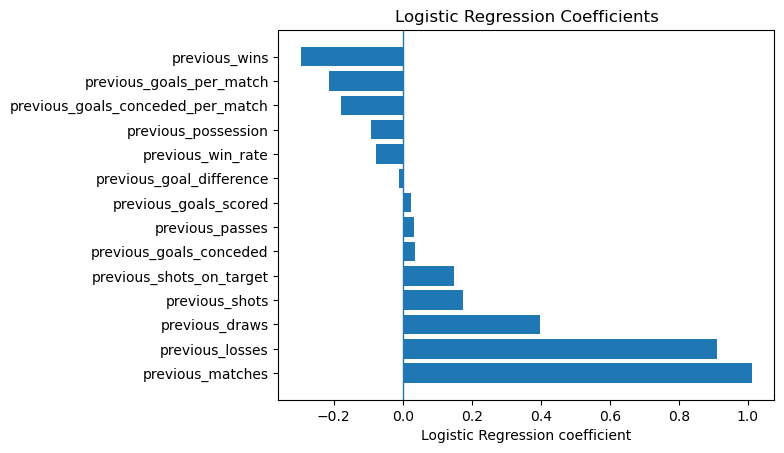

In [25]:
plt.barh(
    coefficients["Feature"],
    coefficients["Coefficient"]
)

plt.xlabel("Logistic Regression coefficient")
plt.title("Logistic Regression Coefficients")
plt.axvline(0, linewidth=1)
plt.show()

Previous matches and previous losses are the largest positive coeff while previous wins and goals per match had negative coefficients.

However these results should be taking with a grain of salt because it doesn't means that losing more matches causes a team to be more likely to win the Champions League.


## Evaluating the Models

I compared the three models using accuracy, precision, recall, F1-score, and ROC-AUC.

Because only one team in the 2025/26 test season was the actual winner.

In [26]:
results = pd.DataFrame({
    "Model": ["Baseline", "Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, baseline_pred),
        accuracy_score(y_test, logistic_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, baseline_pred, zero_division=0),
        precision_score(y_test, logistic_pred, zero_division=0),
        precision_score(y_test, rf_pred, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, baseline_pred, zero_division=0),
        recall_score(y_test, logistic_pred, zero_division=0),
        recall_score(y_test, rf_pred, zero_division=0)
    ],
    "F1": [
        f1_score(y_test, baseline_pred, zero_division=0),
        f1_score(y_test, logistic_pred, zero_division=0),
        f1_score(y_test, rf_pred, zero_division=0)
    ],
    "ROC-AUC": [
        np.nan,
        roc_auc_score(y_test, logistic_prob),
        roc_auc_score(y_test, rf_prob)
    ]
})

results.round(3)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Baseline,0.978,0.000,0.0,0.000,NaN
1,Logistic Regression,0.889,0.167,1.0,0.286,1.000
2,Random Forest,0.956,0.000,0.0,0.000,0.955


The baseline had 97.8% accuracy, but it did not identify any winners. This shows why accuracy alone is not enough for my idea.


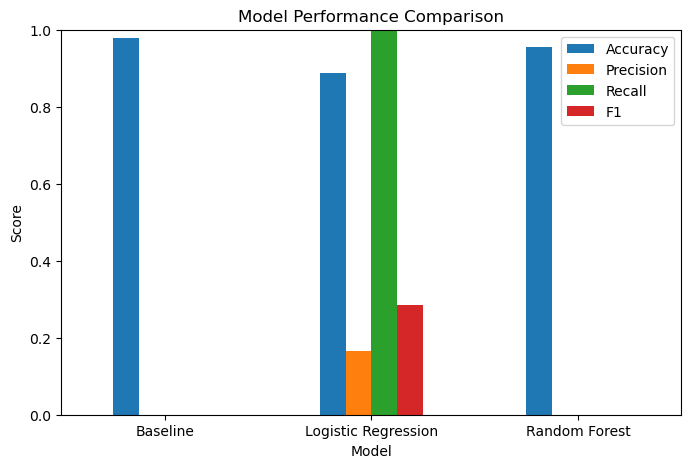

In [27]:
metrics_plot = results.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1"]
]

metrics_plot.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.ylabel("Score")
plt.title("Model Performance Comparison")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.show()

The Logistic Regression model had lower overall accuracy, but it identified the actual winner, giving it a recall of 1.0. Because the goal is to identify potential Champions League winners, I paid more attention to precision, recall, and F1-score rather than accuracy alone.

## Predicting the 2027 Winner

I used the Logistic Regression model as the final model because it was the only model that identified the winner in the 2025/26 test season.

In [29]:
predictions_2027 = pd.read_csv(
    "/Users/nandjath/Desktop/PROJECT-UCL-ML/2027_predictions.csv"
)

predictions_2027.head(10)

,team,source_season,matches,wins,draws,losses,goals_scored,goals_conceded,goal_difference,win_rate,goals_per_match,goals_conceded_per_match,shots,shots_on_target,possession,passes,Winner_Probability,Rank
0,Paris Saint-Germain,25/26,17,11,4,2,49,26,23,0.647059,2.882353,1.529412,18.764706,6.941176,63.647059,629.294118,0.577097,1
1,Atlético Madrid,25/26,16,7,3,6,35,28,7,0.437500,2.187500,1.750000,14.250000,5.437500,49.312500,475.812500,0.250325,2
2,FC Bayern München,25/26,14,11,1,2,43,20,23,0.785714,3.071429,1.428571,18.428571,8.071429,60.785714,623.642857,0.052941,3
3,Club Brugge KV,25/26,14,7,2,5,32,27,5,0.500000,2.285714,1.928571,14.785714,6.571429,49.714286,498.928571,0.039260,4
4,Manchester City,25/26,10,5,1,4,16,14,2,0.500000,1.600000,1.400000,15.600000,6.900000,58.700000,600.800000,0.037818,5
5,Inter,25/26,10,5,0,5,17,12,5,0.500000,1.700000,1.200000,18.000000,5.400000,57.300000,544.600000,0.035508,6
6,Lille,24/25,14,7,3,4,25,17,8,0.500000,1.785714,1.214286,10.785714,4.285714,50.785714,473.142857,0.034497,7
7,Real Madrid,25/26,14,9,0,5,33,20,13,0.642857,2.357143,1.428571,17.428571,6.928571,53.571429,510.857143,0.030831,8
8,Bodø/Glimt,25/26,14,6,3,5,28,24,4,0.428571,2.000000,1.714286,11.357143,5.071429,46.928571,455.214286,0.030763,9
9,FC Barcelona,25/26,12,7,2,3,32,20,12,0.583333,2.666667,1.666667,16.666667,7.083333,63.333333,585.916667,0.019479,10


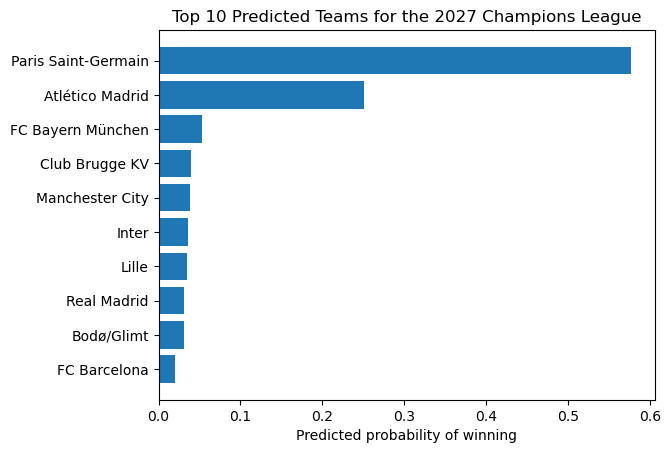

In [30]:
top_10_2027 = predictions_2027.head(10).sort_values(
    "Winner_Probability"
)

plt.barh(
    top_10_2027["team"],
    top_10_2027["Winner_Probability"]
)

plt.xlabel("Predicted probability of winning")
plt.title("Top 10 Predicted Teams for the 2027 Champions League")
plt.show()

Paris Saint-Germain is the model's top prediction for the 2027 Champions League, with an estimated probability of 57.7%.

Atlético Madrid is ranked second at 25.0%, followed by Bayern München at 5.3%. The model therefore gives PSG a clear lead over the other teams.

## Findings

* Previous-season Champions League statistics can be used to build a model that ranks teams by their estimated chance of winning the following season.
* Logistic Regression was the most useful model.
* For the 2027 prediction, Paris Saint-Germain ranked first with a 57.7% predicted probability.
* Atlético Madrid ranked second at 25.0%, followed by Bayern München at 5.3%.
* The results suggest that the model can identify strong candidates, but the predictions should be treated as estimates rather than guaranteed outcomes.


## Limitations & Ethics

* **Small number of winners:** Only five teams in the training data actually won the Champions League, so there are very few positive examples.
* **Class imbalance:** Most teams did not win, so accuracy alone can be misleading.
* **Limited variables:** The model does not include injuries, transfers, managers, or changes in squad quality.
* **Prediction uncertainty:** Past performance does not guarantee future success. The model provides an estimate, not a concrete result.
* **False positive:** that would occur if the model predicted a team to win when it did not, while a false negative would occur if the model failed to identify the eventual winner. These errors are important because predictions could influence how people interpret team performance. The model should just be treated as a tool rather than as a guaranteed predictor used as the sole basis for betting or other high-stakes decisions.



## Reflection

My first model evaluation produced 100% accuracy for all three models. At first, this looked like a strong result, but I found that the test data did not contain a labeled winner.

Because every team was treated as `Winner = 0`, the models could appear accurate without actually identifying a champion.

I changed the approach by using previous-season statistics to predict the following season and by comparing predicted probabilities instead of relying only on accuracy. This made the evaluation more meaningful and helped me select Logistic Regression as the final model.


## AI Usage

I used VS code ai, codex cli tools to help debugging, find inacuracy on the long cvs files, improve wording and clarity of my code. :

- quick translation portuguese - english 
- merging dataset names / uefa names 
- separating and stripping teams that didn't have recents values
- colorful visualizations


## Data & Supporting Sources

* ESPN. (2026). *UEFA Champions League statistics*. ESPN.

* Lago-Ballesteros, J. (2011). Differences in performance indicators between winning and losing teams in the UEFA Champions League. *Journal of Human Kinetics*. https://doi.org/10.2478/V10078-011-0011-3

* Ramos, T. (2026). *UEFA Champions League Historical Match Statistics 2020–2026* [Data set]. Kaggle.

* Saito, T., & Rehmsmeier, M. (2015). The precision-recall plot is more informative than the ROC plot when evaluating binary classifiers on imbalanced datasets. *PLOS ONE, 10*(3), e0118432. https://doi.org/10.1371/journal.pone.0118432

* Union of European Football Associations. (2026). *Meet the 2026/27 Champions League 
league phase teams*.

* Union of European Football Associations. (2026). *UEFA Champions League history*.